In [1]:
from utils.common import prepare_dataset, data_split, train_catboost, calculate_metrics, get_most_important_features, make_lags_dataset

df = prepare_dataset('../trading_small_df.csv',
                    exclude_cols=['cred_limit', 'fin_cond_index', 'tax_regime', 'reg_date', 'Unnamed: 0'], 
                    year_col='year',
                    id_col='vat_num',
                    dflt_col='dflt_year',
                    drop_fin_zeroes=True,
                    drop_ones_after_ones=True)

df = make_lags_dataset(df, [1])

Длина датасета: 153841
Распределение таргета:
dflt_year
0    151926
1      1915
Name: count, dtype: int64
Длина датасета после добавления лаг фичей и отчистки строк с отсутствующими лаг-значениями: 143544
Распределение таргета:
target
0    141649
1      1895
Name: count, dtype: int64


In [2]:
X_train, y_train, X_val, y_val, X_test, y_test = data_split(df, train_year_max=2022, val_year=2023, test_year=2024, target_col="target")

In [3]:
model = train_catboost(X_train, 
                       y_train, 
                       X_val, 
                       y_val,
                       iterations_num=10_000,
                       eval_metric="AUC",
                       learning_rate=0.01,
                       random_seed=42,
                       verbose=200,
                       early_stopping_rounds=200,
                       class_weights=None)

0:	test: 0.7933668	best: 0.7933668 (0)	total: 69.4ms	remaining: 11m 34s
200:	test: 0.8839727	best: 0.8839727 (200)	total: 2.87s	remaining: 2m 19s
400:	test: 0.8941183	best: 0.8941183 (400)	total: 5.33s	remaining: 2m 7s
600:	test: 0.8982139	best: 0.8982139 (600)	total: 7.87s	remaining: 2m 3s
800:	test: 0.8999869	best: 0.9000058 (796)	total: 10.3s	remaining: 1m 58s
1000:	test: 0.9016218	best: 0.9016462 (999)	total: 12.8s	remaining: 1m 54s
1200:	test: 0.9026734	best: 0.9027070 (1196)	total: 15.2s	remaining: 1m 51s
1400:	test: 0.9031229	best: 0.9031359 (1395)	total: 17.6s	remaining: 1m 48s
1600:	test: 0.9037625	best: 0.9037803 (1598)	total: 20s	remaining: 1m 44s
1800:	test: 0.9043950	best: 0.9044074 (1798)	total: 22.4s	remaining: 1m 41s
2000:	test: 0.9048336	best: 0.9048412 (1996)	total: 24.8s	remaining: 1m 39s
2200:	test: 0.9053465	best: 0.9053465 (2200)	total: 27.3s	remaining: 1m 36s
2400:	test: 0.9057396	best: 0.9057461 (2399)	total: 29.7s	remaining: 1m 34s
2600:	test: 0.9059178	best: 0

In [4]:
metrics = calculate_metrics(model, X_test, y_test)

AUC: 0.9353556464182339
Brier: 0.11004989895994449
LogLoss: 0.4410403449572549



Top 20 features by importance:
                             feature  importance
0     debt_to_total_liabilities_lag1   10.741926
1                         roa_ru_tax    5.502929
2                 absolute_liquidity    4.747780
3          debt_to_total_liabilities    4.513405
4        receivables_to_total_assets    3.814470
5              total_assets_turnover    2.813984
6                  net_profit_margin    2.649388
7                  2110_revenue_lag1    2.457437
8                                roa    2.296718
9         total_assets_turnover_lag1    2.092358
10              receivables_turnover    2.071779
11            payables_turnover_lag1    2.004535
12  receivables_to_total_assets_lag1    1.874599
13                owners_equity_lag1    1.818866
14                      2110_revenue    1.387708
15                   net_assets_lag1    1.199652
16              days_inventory_outst    1.106923
17                  days_sales_outst    1.101789
18                        total_debt 

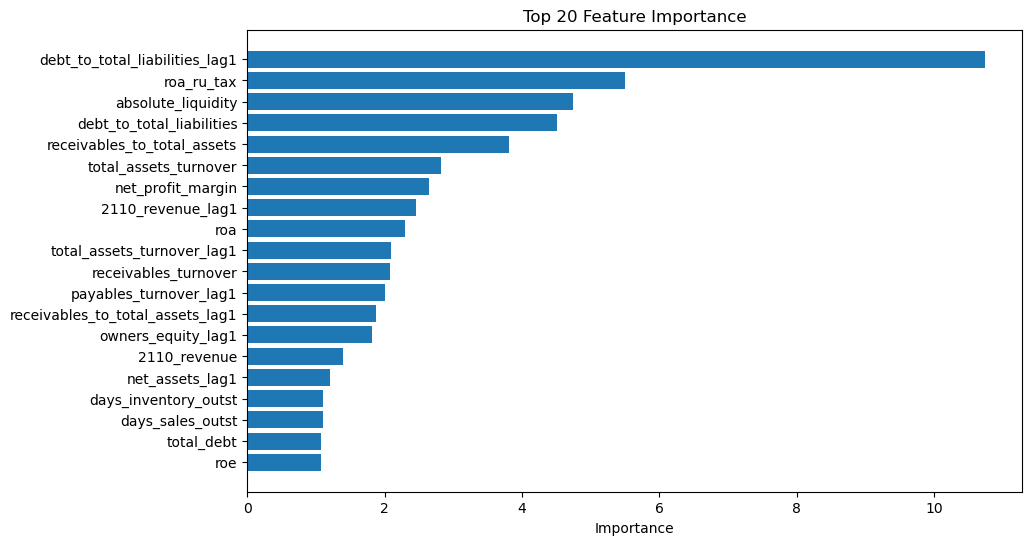

In [5]:
fi_df = get_most_important_features(model, show=20)

In [6]:
from utils.common import calibrate_model

calibrated_model = calibrate_model(model, X_val, y_val)

In [7]:
calibrated_metrics = calculate_metrics(calibrated_model, X_test, y_test)

AUC: 0.9339310112746187
Brier: 0.0873306233421539
LogLoss: 0.29651084362866625


In [8]:
from utils.exp_handler import save_exp

save_exp(X_train, 
         y_train, 
         X_val, 
         y_val, 
         X_test, 
         y_test,
         model,
         metrics=calibrated_metrics,
         fi_df=fi_df,
         calibrated_model=calibrated_model,
         name='small_df_lag1',
         save_data=False)

'exp/small_df_lag1'